# 01 — Data Understanding and Persistence Baseline

This Phase 1 notebook documents the verified data structure, training-only normalization statistics, and a persistence reference. Each sample contains 336 historical hourly observations across 12 input variables; the task is to predict the next 48 hours of specific discharge. Evaluation uses the official validation split. No new 80/20 split is created. Persistence is the reference model before training neural experts.

In [1]:
from pathlib import Path
import json

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Support launching Jupyter with either the repository root or notebooks/ as its working directory.
ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / 'Input' / 'metadata.json').is_file()),
    None,
)
if ROOT is None:
    raise FileNotFoundError('Could not locate repository root containing Input/metadata.json')

INPUT_DIR = ROOT / 'Input'
OUTPUT_DIR = ROOT / 'outputs'
TRAIN_H5 = INPUT_DIR / 'train-001.h5'
TEST_H5 = INPUT_DIR / 'test.h5'

## Metadata summary

The compact summary below comes from the supplied metadata file. The channel table in the next section makes the input order explicit.

In [2]:
with (INPUT_DIR / 'metadata.json').open(encoding='utf-8') as file:
    metadata = json.load(file)

metadata_summary = pd.DataFrame([{
    'history_hours': metadata['history_hours'],
    'forecast_hours': metadata['forecast_hours'],
    'interval_hours': metadata['interval_hours'],
    'target': metadata['target'],
    'target_channel': metadata['target_channel'],
    'train_samples': metadata['samples'].get('train'),
    'validation_samples': metadata['samples'].get('validation'),
    'test_samples': metadata['samples'].get('test'),
}])
display(metadata_summary)
print('Channel names in order:', ', '.join(channel['name'] for channel in metadata['channels']))

,history_hours,forecast_hours,interval_hours,target,target_channel,train_samples,validation_samples,test_samples
0,336,48,1,specific_discharge,11,254000,18142,27983


Channel names in order: convective_fraction, longwave_radiation, potential_energy, potential_evaporation, pressure, shortwave_radiation, specific_humidity, temperature, total_precipitation, wind_u, wind_v, specific_discharge


## Dataset structure verification

HDF5 dataset metadata is inspected without materializing the full arrays. The validation samples used later are read individually in a small selection.

In [3]:
with h5py.File(TRAIN_H5, 'r') as file:
    train_structure = {key: file[key].shape for key in file.keys()}
with h5py.File(TEST_H5, 'r') as file:
    test_keys = list(file.keys())
    test_structure = {key: file[key].shape for key in ('X', 'basin_id')}

print('train-001.h5 keys and shapes:', train_structure)
print('test.h5 keys:', test_keys)
print('test.h5 shapes:', test_structure)

train-001.h5 keys and shapes: {'X': (272142, 336, 12), 'basin_id': (272142,), 'split': (272142,), 'y': (272142, 48), 'y_aux': (272142, 48, 11)}
test.h5 keys: ['X', 'basin_id']
test.h5 shapes: {'X': (27983, 336, 12), 'basin_id': (27983,)}


## Input variables

Channel 11 is the historical target discharge. The other channels are meteorological or hydrometeorological predictors.

In [4]:
channels = sorted(metadata['channels'], key=lambda channel: channel['index'])
variables = pd.DataFrame([{
    'channel': channel['index'],
    'variable': channel['name'],
    'role': ('Historical target discharge' if channel['index'] == metadata['target_channel']
             else 'Meteorological/hydrometeorological predictor'),
} for channel in channels])
display(variables)

,channel,variable,role
0,0,convective_fraction,Meteorological/hydrometeorological predictor
1,1,longwave_radiation,Meteorological/hydrometeorological predictor
2,2,potential_energy,Meteorological/hydrometeorological predictor
3,3,potential_evaporation,Meteorological/hydrometeorological predictor
4,4,pressure,Meteorological/hydrometeorological predictor
5,5,shortwave_radiation,Meteorological/hydrometeorological predictor
6,6,specific_humidity,Meteorological/hydrometeorological predictor
7,7,temperature,Meteorological/hydrometeorological predictor
8,8,total_precipitation,Meteorological/hydrometeorological predictor
9,9,wind_u,Meteorological/hydrometeorological predictor


## Training normalization statistics

These precomputed statistics were calculated using ONLY the training split. This notebook reads the saved values and does not recompute them.

In [5]:
with (OUTPUT_DIR / 'train_stats.json').open(encoding='utf-8') as file:
    train_stats = json.load(file)

x_stats = pd.DataFrame({
    'channel': [channel['name'] for channel in channels],
    'mean': train_stats['x']['mean'],
    'std': train_stats['x']['std'],
})
display(x_stats)
display(pd.DataFrame([{'target': metadata['target'],
                       'mean': train_stats['y']['mean'],
                       'std': train_stats['y']['std']}]))

,channel,mean,std
0,convective_fraction,0.060951,0.205333
1,longwave_radiation,313.379897,64.261232
2,potential_energy,204.519208,500.825597
3,potential_evaporation,0.205742,0.270320
4,pressure,93545.672269,8089.386639
5,shortwave_radiation,199.869451,265.289247
6,specific_humidity,0.007676,0.004390
7,temperature,13.226768,9.861157
8,total_precipitation,0.132268,0.670326
9,wind_u,1.003500,3.063596


,target,mean,std
0,specific_discharge,0.066194,0.161164


## Example validation trajectories

The following figures show three validation examples. Historical discharge is limited to the final 96 hours for readability; future observations and the 48-hour persistence forecast are shown after the forecast origin.

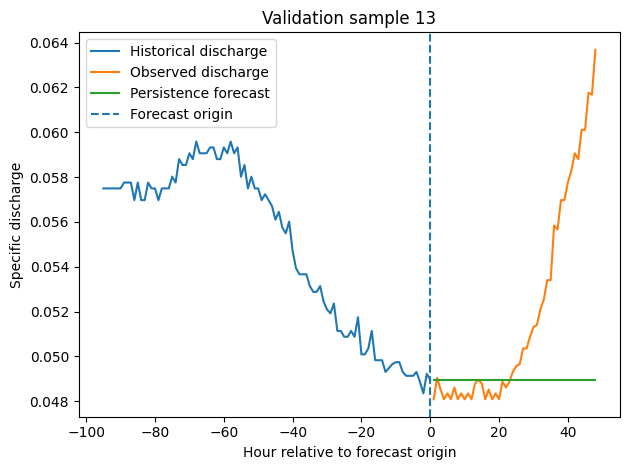

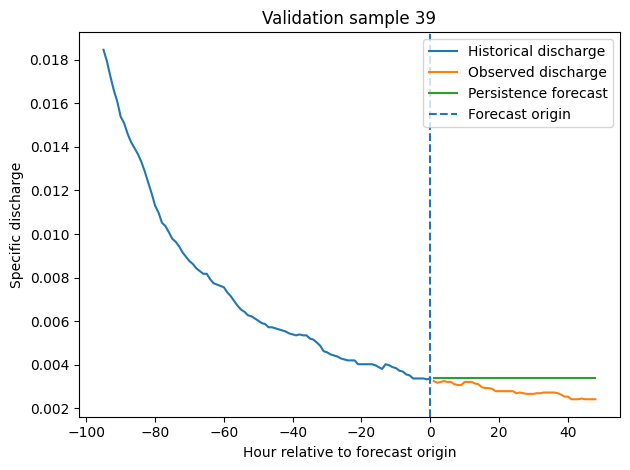

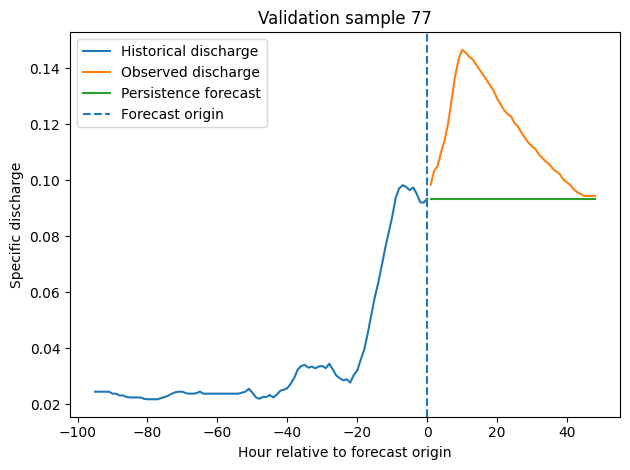

In [6]:
with h5py.File(TRAIN_H5, 'r') as file:
    validation_indices = np.flatnonzero(file['split'][:] == 1)[:3]
    for sample_index in validation_indices:
        history = file['X'][sample_index, -96:, metadata['target_channel']]
        future = file['y'][sample_index]
        persistence = np.repeat(history[-1], metadata['forecast_hours'])

        history_hours = np.arange(-len(history) + 1, 1)
        forecast_hours = np.arange(1, metadata['forecast_hours'] + 1)
        fig, ax = plt.subplots()
        ax.plot(history_hours, history, label='Historical discharge')
        ax.plot(forecast_hours, future, label='Observed discharge')
        ax.plot(forecast_hours, persistence, label='Persistence forecast')
        ax.axvline(0, linestyle='--', label='Forecast origin')
        ax.set(title=f'Validation sample {int(sample_index)}',
               xlabel='Hour relative to forecast origin', ylabel='Specific discharge')
        ax.legend()
        fig.tight_layout()
        plt.show()

## Persistence baseline results

Persistence repeats the last observed historical discharge value across all 48 forecast hours. These validation results are the reference for comparison with learned models; the baseline is reported without a qualitative rating.

In [7]:
with (OUTPUT_DIR / 'persistence_validation.json').open(encoding='utf-8') as file:
    persistence_results = json.load(file)

display(pd.DataFrame([persistence_results['global']]))
print('Split:', persistence_results['split'])
print('Validation samples:', persistence_results['n_samples'])

,mae,rmse,nse
0,0.024464,0.137859,0.354547


Split: validation
Validation samples: 18142


## Horizon-dependent baseline error


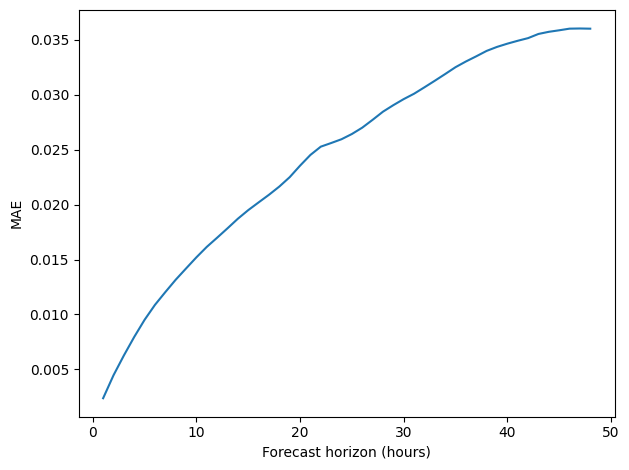

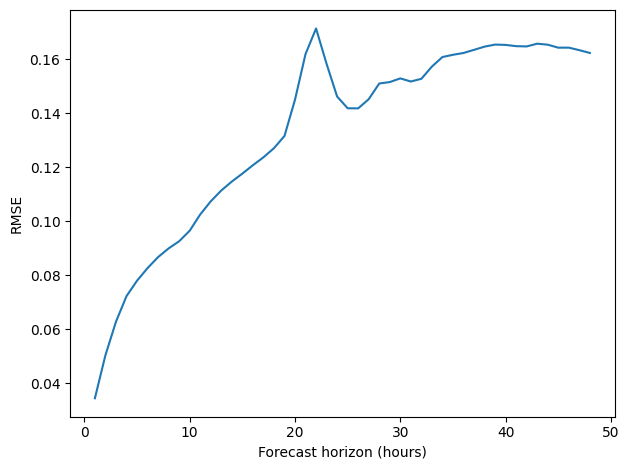

In [8]:
horizons = np.arange(1, len(persistence_results['per_horizon']['mae']) + 1)

fig, ax = plt.subplots()
ax.plot(horizons, persistence_results['per_horizon']['mae'])
ax.set(xlabel='Forecast horizon (hours)', ylabel='MAE')
fig.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.plot(horizons, persistence_results['per_horizon']['rmse'])
ax.set(xlabel='Forecast horizon (hours)', ylabel='RMSE')
fig.tight_layout()
plt.show()

In [ ]:
## Phase 1 conclusion

The dataset loader and stored structure have been verified, normalization statistics are derived from the training split only, and persistence has been established on the official validation split. The next stage is to train and evaluate independent neural experts: LSTM, GRU, LSTM Seq2Seq with Attention, and Informer. Router development follows the expert comparisons in a later phase.

In [3]:
import h5py
import numpy as np
import pandas as pd

TRAIN_H5 = INPUT_DIR / "train-001.h5"
TEST_H5 = INPUT_DIR / "test.h5"

# ---------------------------------------------------------
# TRAIN / VALIDATION
# ---------------------------------------------------------

with h5py.File(TRAIN_H5, "r") as f:
    basin_id = f["basin_id"][:]
    split = f["split"][:]

train_basins = basin_id[split == 0]
val_basins   = basin_id[split == 1]

# ---------------------------------------------------------
# TEST
# ---------------------------------------------------------

with h5py.File(TEST_H5, "r") as f:
    test_basins = f["basin_id"][:]

# ---------------------------------------------------------
# BASIC SUMMARY
# ---------------------------------------------------------

print("Samples")
print("--------------------------")
print(f"Train:      {len(train_basins):,}")
print(f"Validation: {len(val_basins):,}")
print(f"Test:       {len(test_basins):,}")

print("\nUnique basin_id")
print("--------------------------")
print(f"Train:      {len(np.unique(train_basins)):,}")
print(f"Validation: {len(np.unique(val_basins)):,}")
print(f"Test:       {len(np.unique(test_basins)):,}")

Samples
--------------------------
Train:      254,000
Validation: 18,142
Test:       27,983

Unique basin_id
--------------------------
Train:      508
Validation: 508
Test:       508


In [4]:
train_counts = (
    pd.Series(train_basins)
    .value_counts()
    .rename("train")
)

val_counts = (
    pd.Series(val_basins)
    .value_counts()
    .rename("validation")
)

test_counts = (
    pd.Series(test_basins)
    .value_counts()
    .rename("test")
)

basin_distribution = pd.concat(
    [train_counts, val_counts, test_counts],
    axis=1
).fillna(0).astype(int)

basin_distribution.index.name = "basin_id"

display(
    basin_distribution
    .sort_values("train", ascending=False)
    .head(30)
)

,train,validation,test
basin_id,,,
205,500,40,60
221,500,29,43
494,500,40,60
8,500,38,60
491,500,31,57
443,500,40,60
111,500,40,60
440,500,25,37
394,500,36,60


In [5]:
train_set = set(np.unique(train_basins))
val_set   = set(np.unique(val_basins))
test_set  = set(np.unique(test_basins))

print("Basin overlap")
print("----------------------------")

print(
    "Train ∩ Validation:",
    len(train_set & val_set)
)

print(
    "Train ∩ Test:",
    len(train_set & test_set)
)

print(
    "Validation ∩ Test:",
    len(val_set & test_set)
)

print(
    "Test basins NOT seen in train:",
    len(test_set - train_set)
)

print(
    "Validation basins NOT seen in train:",
    len(val_set - train_set)
)

Basin overlap
----------------------------
Train ∩ Validation: 508
Train ∩ Test: 508
Validation ∩ Test: 508
Test basins NOT seen in train: 0
Validation basins NOT seen in train: 0


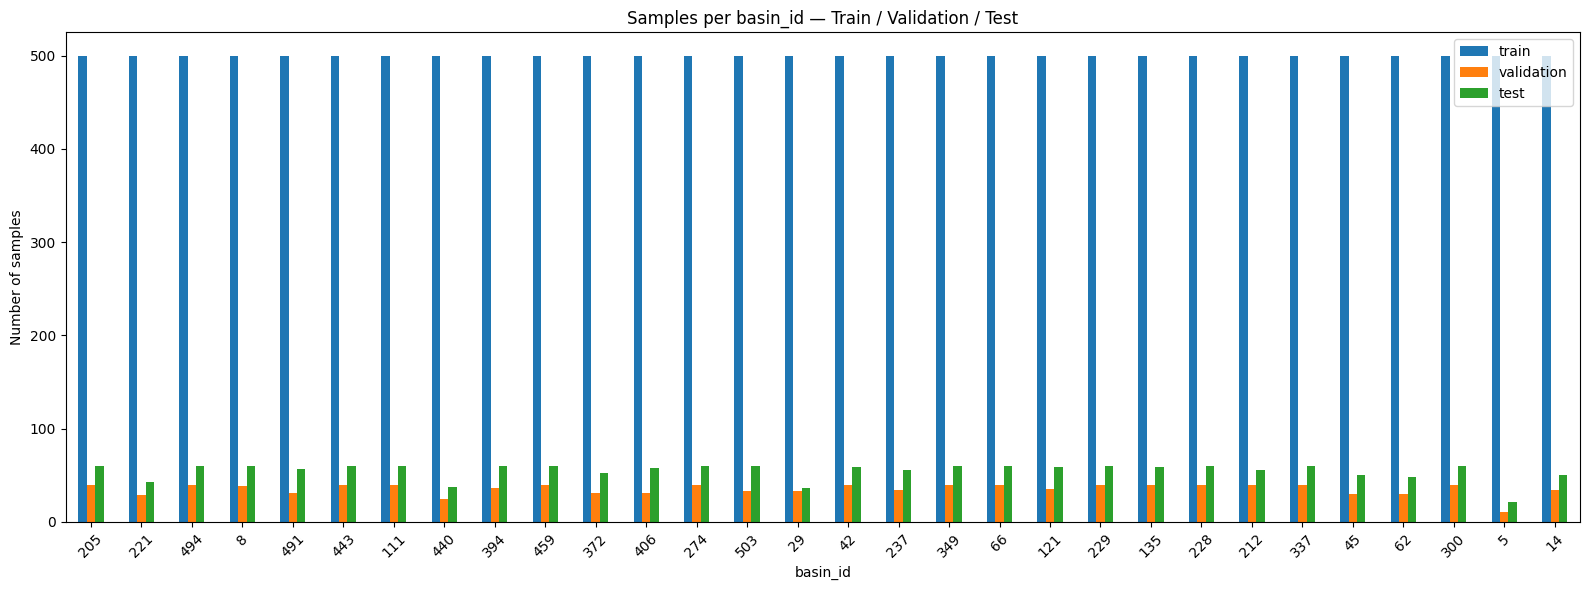

In [6]:
import matplotlib.pyplot as plt

plot_df = (
    basin_distribution
    .sort_values("train", ascending=False)
    .head(30)
)

ax = plot_df.plot(
    kind="bar",
    figsize=(16, 6)
)

ax.set_title("Samples per basin_id — Train / Validation / Test")
ax.set_xlabel("basin_id")
ax.set_ylabel("Number of samples")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

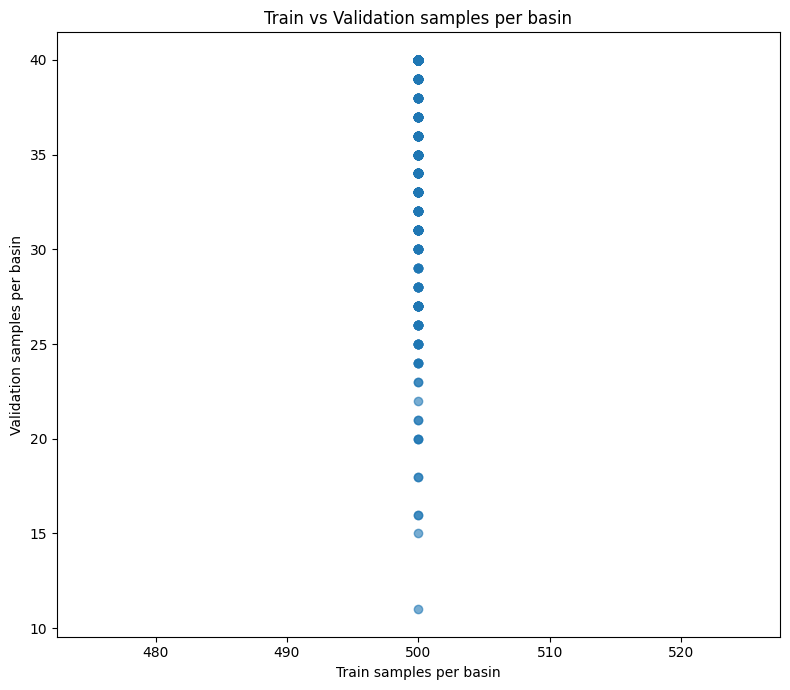

In [7]:
fig, ax = plt.subplots(figsize=(8, 7))

common = basin_distribution[
    (basin_distribution["train"] > 0) &
    (basin_distribution["validation"] > 0)
]

ax.scatter(
    common["train"],
    common["validation"],
    alpha=0.6
)

ax.set_xlabel("Train samples per basin")
ax.set_ylabel("Validation samples per basin")
ax.set_title("Train vs Validation samples per basin")

plt.tight_layout()
plt.show()

In [10]:
from pprint import pprint

pprint(metadata, sort_dicts=False)
# print(json.dumps(metadata, indent=2))

{'history_hours': 336,
 'forecast_hours': 48,
 'interval_hours': 1,
 'target': 'specific_discharge',
 'target_units': 'mm/h',
 'target_units_evidence': 'nombre de la variable original (sin conversion '
                          'aplicada)',
 'target_channel': 11,
 'axis_order': ['sample', 'time', 'channel'],
 'dtype': 'float32',
 'channels': [{'index': 0,
               'name': 'convective_fraction',
               'description': 'Fraccion convectiva',
               'units_declared_in_source': None},
              {'index': 1,
               'name': 'longwave_radiation',
               'description': 'Radiacion de onda larga',
               'units_declared_in_source': None},
              {'index': 2,
               'name': 'potential_energy',
               'description': 'Energia potencial',
               'units_declared_in_source': None},
              {'index': 3,
               'name': 'potential_evaporation',
               'description': 'Evaporacion potencial',
             

## Exploratory Data Analysis (EDA)

Exploración y auditoría de calidad del dataset

In [15]:
from pathlib import Path

print("Current working directory:")
print(Path.cwd())

Current working directory:
C:\GEOSPATIAL\moe-streamflow-forecasting\notebooks


In [16]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

INPUT_DIR = PROJECT_ROOT / "Input"
TRAIN_H5 = INPUT_DIR / "train-001.h5"
TEST_H5 = INPUT_DIR / "test.h5"

TARGET_CHANNEL = 11
CHUNK_SIZE = 512

print("TRAIN_H5:", TRAIN_H5)
print("TEST_H5:", TEST_H5)
print("Train exists:", TRAIN_H5.exists())
print("Test exists:", TEST_H5.exists())

TRAIN_H5: C:\GEOSPATIAL\moe-streamflow-forecasting\Input\train-001.h5
TEST_H5: C:\GEOSPATIAL\moe-streamflow-forecasting\Input\test.h5
Train exists: True
Test exists: True


## 1. Resumen general por split y basin

In [17]:
with h5py.File(TRAIN_H5, "r") as f:
    basin_id = f["basin_id"][:]
    split = f["split"][:]

train_basins = basin_id[split == 0]
val_basins = basin_id[split == 1]

with h5py.File(TEST_H5, "r") as f:
    test_basins = f["basin_id"][:]

def counts_by_basin(values, name):
    return pd.Series(values).value_counts().sort_index().rename(name)

basin_summary = pd.concat([
    counts_by_basin(train_basins, "train"),
    counts_by_basin(val_basins, "validation"),
    counts_by_basin(test_basins, "test"),
], axis=1).fillna(0).astype(int)

display(basin_summary.describe())

print("Unique basins")
print("Train:", basin_summary["train"].gt(0).sum())
print("Validation:", basin_summary["validation"].gt(0).sum())
print("Test:", basin_summary["test"].gt(0).sum())

display(basin_summary.head(20))

,train,validation,test
count,508.0,508.000000,508.000000
mean,500.0,35.712598,55.084646
std,0.0,5.375457,7.359380
min,500.0,11.000000,21.000000
25%,500.0,33.000000,52.000000
50%,500.0,38.000000,60.000000
75%,500.0,40.000000,60.000000
max,500.0,40.000000,60.000000


Unique basins
Train: 508
Validation: 508
Test: 508


,train,validation,test
0,500,40,60
1,500,40,60
2,500,34,55
3,500,40,60
4,500,39,60
5,500,11,21
6,500,40,57
7,500,35,59
8,500,38,60
9,500,40,60


## 2.Visualizar distribución de muestras por basin

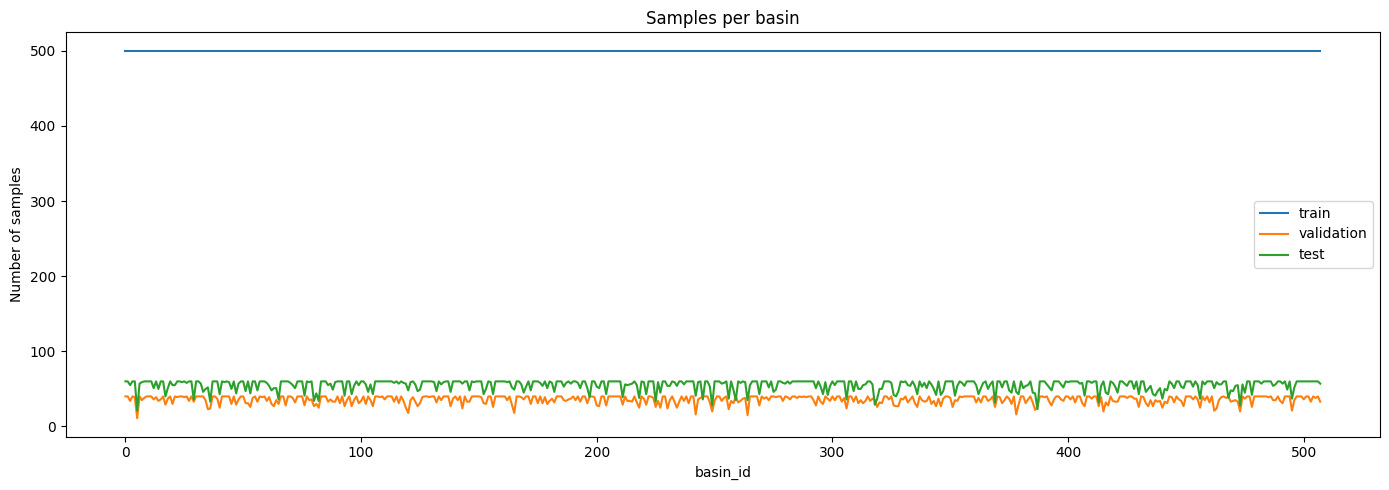

In [18]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(basin_summary.index, basin_summary["train"], label="train")
ax.plot(basin_summary.index, basin_summary["validation"], label="validation")
ax.plot(basin_summary.index, basin_summary["test"], label="test")

ax.set_xlabel("basin_id")
ax.set_ylabel("Number of samples")
ax.set_title("Samples per basin")
ax.legend()

plt.tight_layout()
plt.show()

## 3. Auditoría de NaN / Inf / ceros

In [19]:
def audit_h5(path, include_targets=True, chunk_size=512):
    result = {}

    with h5py.File(path, "r") as f:
        X = f["X"]
        n = X.shape[0]
        channels = X.shape[-1]

        x_nan = np.zeros(channels, dtype=np.int64)
        x_inf = np.zeros(channels, dtype=np.int64)
        x_zero = np.zeros(channels, dtype=np.int64)
        x_count = np.zeros(channels, dtype=np.int64)

        x_min = np.full(channels, np.inf)
        x_max = np.full(channels, -np.inf)

        for start in range(0, n, chunk_size):
            stop = min(start + chunk_size, n)
            xb = X[start:stop]

            flat = xb.reshape(-1, channels)

            x_nan += np.isnan(flat).sum(axis=0)
            x_inf += np.isinf(flat).sum(axis=0)
            x_zero += (flat == 0).sum(axis=0)
            x_count += flat.shape[0]

            finite = np.where(np.isfinite(flat), flat, np.nan)

            x_min = np.fmin(x_min, np.nanmin(finite, axis=0))
            x_max = np.fmax(x_max, np.nanmax(finite, axis=0))

        result["X"] = pd.DataFrame({
            "channel": np.arange(channels),
            "nan_count": x_nan,
            "inf_count": x_inf,
            "zero_fraction": x_zero / x_count,
            "min": x_min,
            "max": x_max,
        })

        if include_targets and "y" in f:
            y = f["y"]
            y_nan = 0
            y_inf = 0
            y_zero = 0
            y_count = 0
            y_min = np.inf
            y_max = -np.inf

            for start in range(0, n, chunk_size):
                stop = min(start + chunk_size, n)
                yb = y[start:stop]

                y_nan += np.isnan(yb).sum()
                y_inf += np.isinf(yb).sum()
                y_zero += (yb == 0).sum()
                y_count += yb.size

                finite = yb[np.isfinite(yb)]

                if finite.size:
                    y_min = min(y_min, finite.min())
                    y_max = max(y_max, finite.max())

            result["y"] = {
                "nan_count": int(y_nan),
                "inf_count": int(y_inf),
                "zero_fraction": float(y_zero / y_count),
                "min": float(y_min),
                "max": float(y_max),
            }

    return result

In [22]:
train_audit = audit_h5(TRAIN_H5, include_targets=True)

display(train_audit["X"])
print(train_audit["y"])

,channel,nan_count,inf_count,zero_fraction,min,max
0,0,0,0,0.862390,0.000000,1.000000
1,1,0,0,0.000000,99.065369,532.741943
2,2,0,0,0.490675,0.000000,6343.836914
3,3,0,0,0.000026,-0.827489,1.596727
4,4,0,0,0.000000,64832.167969,104319.890625
5,5,0,0,0.481696,0.000000,1276.191528
6,6,0,0,0.000000,0.000030,0.026991
7,7,0,0,0.000006,-32.520000,47.538933
8,8,0,0,0.771807,0.000000,89.392891
9,9,0,0,0.000027,-22.650000,24.401419


{'nan_count': 0, 'inf_count': 0, 'zero_fraction': 0.032949556971483024, 'min': 0.0, 'max': 27.32405662536621}


## 4. Añadir nombres de variables

In [23]:
channel_names = [
    "convective_fraction",
    "longwave_radiation",
    "potential_energy",
    "potential_evaporation",
    "pressure",
    "shortwave_radiation",
    "specific_humidity",
    "temperature",
    "total_precipitation",
    "wind_u",
    "wind_v",
    "specific_discharge",
]

x_audit = train_audit["X"].copy()
x_audit["variable"] = channel_names

display(
    x_audit[
        ["channel", "variable", "nan_count", "inf_count",
         "zero_fraction", "min", "max"]
    ]
)

,channel,variable,nan_count,inf_count,zero_fraction,min,max
0,0,convective_fraction,0,0,0.862390,0.000000,1.000000
1,1,longwave_radiation,0,0,0.000000,99.065369,532.741943
2,2,potential_energy,0,0,0.490675,0.000000,6343.836914
3,3,potential_evaporation,0,0,0.000026,-0.827489,1.596727
4,4,pressure,0,0,0.000000,64832.167969,104319.890625
5,5,shortwave_radiation,0,0,0.481696,0.000000,1276.191528
6,6,specific_humidity,0,0,0.000000,0.000030,0.026991
7,7,temperature,0,0,0.000006,-32.520000,47.538933
8,8,total_precipitation,0,0,0.771807,0.000000,89.392891
9,9,wind_u,0,0,0.000027,-22.650000,24.401419


## 5. Distribución del target

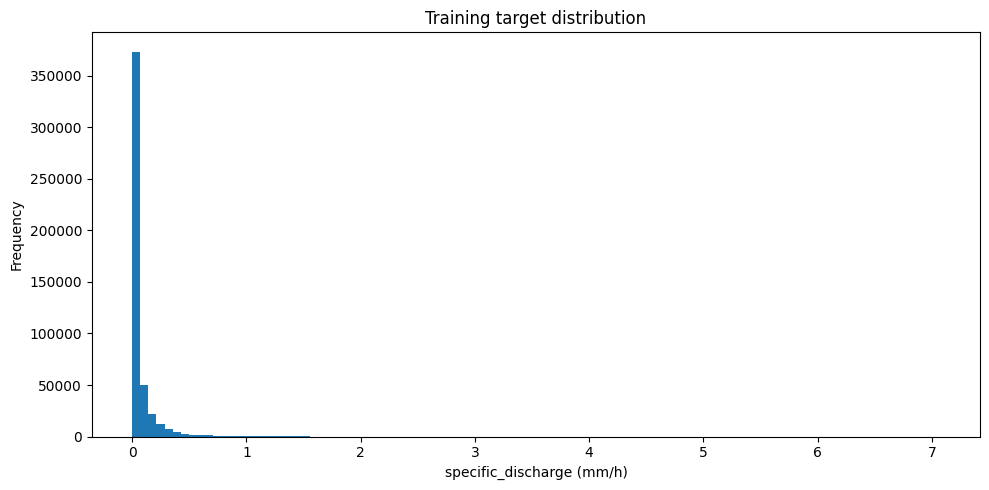

count    480000.000000
mean          0.065234
std           0.151230
min           0.000000
50%           0.020752
90%           0.163689
95%           0.278881
99%           0.651042
99.9%         1.669379
max           7.068375
dtype: float64


In [21]:
sample_y = []

with h5py.File(TRAIN_H5, "r") as f:
    y = f["y"]
    split = f["split"][:]

    train_idx = np.flatnonzero(split == 0)

    # muestra reproducible, no todo el dataset
    rng = np.random.default_rng(42)
    selected = rng.choice(
        train_idx,
        size=min(10000, len(train_idx)),
        replace=False
    )

    selected.sort()
    sample_y = y[selected].ravel()

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(sample_y, bins=100)
ax.set_xlabel("specific_discharge (mm/h)")
ax.set_ylabel("Frequency")
ax.set_title("Training target distribution")

plt.tight_layout()
plt.show()

print(pd.Series(sample_y).describe(
    percentiles=[0.5, 0.9, 0.95, 0.99, 0.999]
))

## 6. Distribución por cuenca

In [24]:
rng = np.random.default_rng(42)

selected_basins = rng.choice(
    np.unique(train_basins),
    size=8,
    replace=False
)

records = []

with h5py.File(TRAIN_H5, "r") as f:
    y = f["y"]
    basin = f["basin_id"][:]
    split = f["split"][:]

    for b in selected_basins:
        idx = np.flatnonzero((basin == b) & (split == 0))

        values = y[idx].ravel()

        records.append({
            "basin_id": b,
            "n_samples": len(idx),
            "mean_q": values.mean(),
            "median_q": np.median(values),
            "p95_q": np.percentile(values, 95),
            "p99_q": np.percentile(values, 99),
            "max_q": values.max(),
        })

display(pd.DataFrame(records))

,basin_id,n_samples,mean_q,median_q,p95_q,p99_q,max_q
0,43,500,0.338112,0.212973,1.116925,2.205477,6.128889
1,354,500,0.117204,0.040105,0.487229,0.938919,2.103862
2,434,500,0.002575,0.001772,0.006956,0.013145,0.031107
3,329,500,0.045394,0.034024,0.098505,0.251683,2.465800
4,218,500,0.130027,0.053167,0.428881,1.282870,19.829605
5,221,500,0.001681,0.000199,0.005636,0.030634,0.452698
6,44,500,0.045009,0.020927,0.142216,0.316894,1.650646
7,388,500,0.243606,0.149209,0.793878,1.776321,4.604491


## 7. Buscar duplicados exactos de ventanas

In [25]:
import hashlib

def fingerprint_array(arr):
    return hashlib.md5(
        np.ascontiguousarray(arr).tobytes()
    ).hexdigest()

rng = np.random.default_rng(42)

with h5py.File(TRAIN_H5, "r") as f:
    n = len(f["X"])

    selected = rng.choice(
        n,
        size=min(20000, n),
        replace=False
    )

    hashes = []

    for i in selected:
        hashes.append(fingerprint_array(f["X"][i]))

hash_series = pd.Series(hashes)

print("Samples checked:", len(hash_series))
print("Unique fingerprints:", hash_series.nunique())
print("Exact duplicate windows:", hash_series.duplicated().sum())

Samples checked: 20000
Unique fingerprints: 20000
Exact duplicate windows: 0


## 8. Comprobar posibles ventanas desplazadas

In [26]:
def shifted_similarity(a, b):
    """
    Compare A[1:] with B[:-1].
    1.0 means almost perfect hourly shift continuity.
    """
    a2 = a[1:].reshape(-1)
    b2 = b[:-1].reshape(-1)

    if np.std(a2) == 0 or np.std(b2) == 0:
        return np.nan

    return np.corrcoef(a2, b2)[0, 1]

In [27]:
rng = np.random.default_rng(42)

with h5py.File(TRAIN_H5, "r") as f:
    basin = f["basin_id"][:]
    split = f["split"][:]
    X = f["X"]

    test_basins_for_overlap = rng.choice(
        np.unique(train_basins),
        size=10,
        replace=False
    )

    results = []

    for b in test_basins_for_overlap:
        idx = np.flatnonzero((basin == b) & (split == 0))

        # primeras parejas en el orden original
        for i1, i2 in zip(idx[:-1][:20], idx[1:][:20]):
            corr = shifted_similarity(
                X[i1],
                X[i2]
            )

            results.append({
                "basin_id": b,
                "id1": i1,
                "id2": i2,
                "shift_corr": corr,
            })

shift_df = pd.DataFrame(results)

display(shift_df.describe())
display(
    shift_df.sort_values("shift_corr", ascending=False).head(20)
)

,basin_id,id1,id2,shift_corr
count,200.000000,200.000000,200.00000,200.000000
mean,217.000000,5702.435000,6258.37000,0.999953
std,144.392681,3683.890939,3737.10327,0.000036
min,43.000000,56.000000,79.00000,0.999688
25%,47.000000,2461.500000,3203.50000,0.999942
50%,218.500000,5148.000000,5772.50000,0.999961
75%,352.000000,8506.250000,8908.00000,0.999974
max,432.000000,14248.000000,14271.00000,0.999992


,basin_id,id1,id2,shift_corr
6,43,1901,4393,0.999992
7,43,4393,5408,0.999992
26,386,4751,4777,0.999992
28,386,5253,7126,0.999991
8,43,5408,7195,0.999989
5,43,1469,1901,0.999988
65,327,1869,2481,0.999987
27,386,4777,5253,0.999987
37,386,9127,9469,0.999987
9,43,7195,7473,0.999986


## 9. Mejor test: igualdad exacta en el shift

In [28]:
def shifted_exact_fraction(a, b, atol=1e-6):
    return np.mean(
        np.isclose(
            a[1:],
            b[:-1],
            atol=atol,
            rtol=0
        )
    )

In [29]:
results = []

with h5py.File(TRAIN_H5, "r") as f:
    basin = f["basin_id"][:]
    split = f["split"][:]
    X = f["X"]

    for b in np.unique(train_basins)[:20]:
        idx = np.flatnonzero((basin == b) & (split == 0))

        for i1, i2 in zip(idx[:-1][:20], idx[1:][:20]):

            frac = shifted_exact_fraction(
                X[i1],
                X[i2]
            )

            results.append({
                "basin_id": b,
                "id1": i1,
                "id2": i2,
                "shift_exact_fraction": frac,
            })

shift_exact_df = pd.DataFrame(results)

display(
    shift_exact_df["shift_exact_fraction"].describe()
)

count    400.000000
mean       0.170999
std        0.038339
min        0.066169
25%        0.141978
50%        0.168035
75%        0.198570
max        0.293284
Name: shift_exact_fraction, dtype: float64

## 10. Último test: overlap temporal entre ventanas

In [30]:
import h5py
import numpy as np
import pandas as pd

def overlap_score_discharge(x1, y1, x2, y2, atol=1e-6):
    """
    Compara dos muestras suponiendo que la segunda podría estar desplazada 1 hora.
    
    Retorna:
    - history_exact_fraction:
        fracción de coincidencia entre x1[1:, discharge] y x2[:-1, discharge]
    - future_exact_fraction:
        fracción de coincidencia entre y1[1:] y y2[:-1]
    - history_mae:
        diferencia media absoluta entre historias desplazadas
    - future_mae:
        diferencia media absoluta entre futuros desplazados
    """
    
    q1_hist = x1[:, TARGET_CHANNEL]
    q2_hist = x2[:, TARGET_CHANNEL]
    
    history_exact = np.mean(
        np.isclose(
            q1_hist[1:],
            q2_hist[:-1],
            atol=atol,
            rtol=0
        )
    )
    
    future_exact = np.mean(
        np.isclose(
            y1[1:],
            y2[:-1],
            atol=atol,
            rtol=0
        )
    )
    
    history_mae = np.mean(np.abs(q1_hist[1:] - q2_hist[:-1]))
    future_mae = np.mean(np.abs(y1[1:] - y2[:-1]))
    
    return history_exact, future_exact, history_mae, future_mae

In [31]:
results = []

rng = np.random.default_rng(42)

with h5py.File(TRAIN_H5, "r") as f:
    basin = f["basin_id"][:]
    split = f["split"][:]
    X = f["X"]
    y = f["y"]

    selected_basins = rng.choice(
        np.unique(train_basins),
        size=20,
        replace=False
    )

    for b in selected_basins:
        idx = np.flatnonzero((basin == b) & (split == 0))

        # solo primeras 30 parejas por basin para audit rápido
        for i1, i2 in zip(idx[:-1][:30], idx[1:][:30]):

            hist_exact, fut_exact, hist_mae, fut_mae = overlap_score_discharge(
                X[i1], y[i1],
                X[i2], y[i2]
            )

            results.append({
                "basin_id": int(b),
                "id1": int(i1),
                "id2": int(i2),
                "history_exact_fraction": hist_exact,
                "future_exact_fraction": fut_exact,
                "history_shift_mae": hist_mae,
                "future_shift_mae": fut_mae,
            })

overlap_df = pd.DataFrame(results)

display(overlap_df.describe())
display(
    overlap_df.sort_values(
        ["future_exact_fraction", "history_exact_fraction"],
        ascending=False
    ).head(20)
)

,basin_id,id1,id2,history_exact_fraction,future_exact_fraction,history_shift_mae,future_shift_mae
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,267.950000,8101.835000,8629.988333,0.012945,0.015390,0.057517,0.057652
std,140.513894,4880.557925,4908.861406,0.089938,0.112639,0.101665,0.114269
min,42.000000,26.000000,227.000000,0.000000,0.000000,0.000000,0.000000
25%,184.750000,4148.000000,4480.000000,0.000000,0.000000,0.004377,0.002902
50%,291.500000,8034.000000,8674.500000,0.000000,0.000000,0.021351,0.013979
75%,379.750000,11793.250000,12454.000000,0.000000,0.000000,0.071533,0.050144
max,487.000000,20815.000000,20940.000000,1.000000,1.000000,0.878195,0.850451


,basin_id,id1,id2,history_exact_fraction,future_exact_fraction,history_shift_mae,future_shift_mae
38,360,2077,2104,1.000000,1.000000,0.000000,0.000000e+00
49,360,8537,8838,1.000000,1.000000,0.000000,0.000000e+00
55,360,12562,12593,1.000000,1.000000,0.000000,0.000000e+00
56,360,12593,12623,1.000000,1.000000,0.000000,0.000000e+00
48,360,7343,8537,0.408955,1.000000,0.000004,0.000000e+00
47,360,5923,7343,0.405970,1.000000,0.000004,0.000000e+00
403,424,4310,4633,0.486567,0.978723,0.000016,3.141728e-07
58,360,13309,13947,0.092537,0.680851,0.000044,9.635318e-07
347,42,10819,11531,0.002985,0.382979,0.000828,1.304898e-04
2,379,1855,2664,0.000000,0.297872,0.001727,2.604254e-04
